# data load

In [47]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.combine import SMOTETomek
from imblearn.ensemble import EasyEnsembleClassifier

import shap


c:\Users\관리자\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [44]:
# 현재 노트북 위치
BASE_DIR = Path().resolve()

# 프로젝트 루트 (notebooks의 상위 폴더)
PROJECT_ROOT = BASE_DIR.parent

# data 폴더
DATA_DIR = PROJECT_ROOT / "data"

# data 파일
path1 = DATA_DIR / "all_data_v1_update.csv"
trade_area_path = DATA_DIR / "서울시 상권분석서비스(길단위인구-상권).csv"

# data load
df = pd.read_csv(path1, encoding="utf-8")
trade_area_info = pd.read_csv(trade_area_path, encoding="cp949")

# 파생변수 생성

In [45]:
# -----------------------
# 1) 성별 컬럼 정의
# -----------------------
female_cols = [c for c in df.columns if c.startswith("여성")]
male_cols   = [c for c in df.columns if c.startswith("남성")]

# -----------------------
# 2) 행 단위 성별 합계
# -----------------------
df["여성_합계"] = df[female_cols].sum(axis=1)
df["남성_합계"] = df[male_cols].sum(axis=1)


In [46]:
# -----------------------
# 1) 연령대 컬럼 정의
# -----------------------
age_cols = {
    "20대": [c for c in df.columns if "20대" in c],
    "30대": [c for c in df.columns if "30대" in c],
    "40대": [c for c in df.columns if "40대" in c],
    "50대": [c for c in df.columns if "50대" in c],
    "60대": [c for c in df.columns if "60대" in c],

}

# -----------------------
# 2) 행(row) 단위 연령대 합계
# -----------------------
for age, cols in age_cols.items():
    df[f"{age}_합계"] = df[cols].sum(axis=1)

In [47]:
df["배달여부"] = (
    df.groupby("가맹점구분번호")["배달매출금액 비율"]
      .transform(lambda x: (x != 0).any())
      .astype(int)
)

# 분기별 요약변수 생성

In [48]:
# 분기 컬럼 생성
df["기준년월"] = pd.to_datetime(df["기준년월"])
df["연도"] = df["기준년월"].dt.year
df["분기"] = df["기준년월"].dt.quarter

In [49]:
target_cols = ['가맹점 운영개월수 구간','배달여부', '배달매출금액 비율','객단가 구간', '동일 업종 내 해지 가맹점 비중',
               '여성_합계', '남성_합계',
               '20대_합계', '30대_합계', '40대_합계', '50대_합계','60대_합계',]


In [50]:
# 상점×분기 압축 (평균/표준편차)
summary_df = (
    df.groupby(["가맹점구분번호", "연도", "분기"], dropna=False)[target_cols]
      .agg(["mean", "std"])
)
# 컬럼명 깔끔하게: (컬럼, mean/std) → "컬럼_mean" 형태
summary_df.columns = [f"{col}_{stat}" for col, stat in summary_df.columns]
summary_df = summary_df.reset_index()

# 선택: 표준편차가 NaN(분기 데이터 1개뿐이면 std가 NaN)인 경우 0으로
std_cols = [c for c in summary_df.columns if c.endswith("_std")]
summary_df[std_cols] = summary_df[std_cols].fillna(0)


In [51]:
summary_df.head()

,가맹점구분번호,연도,분기,가맹점 운영개월수 구간_mean,가맹점 운영개월수 구간_std,배달여부_mean,배달여부_std,배달매출금액 비율_mean,배달매출금액 비율_std,객단가 구간_mean,...,20대_합계_mean,20대_합계_std,30대_합계_mean,30대_합계_std,40대_합계_mean,40대_합계_std,50대_합계_mean,50대_합계_std,60대_합계_mean,60대_합계_std
0,000F03E44A,2023,1,5.000000,0.00000,1.0,0.0,69.283333,0.0,5.333333,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.00000
1,000F03E44A,2023,2,5.000000,0.00000,1.0,0.0,69.283333,0.0,5.000000,...,0.000000,0.000000,63.900000,12.733028,0.000000,0.000000,36.100000,12.733028,0.000000,0.00000
2,000F03E44A,2023,3,5.000000,0.00000,1.0,0.0,69.283333,0.0,5.666667,...,0.000000,0.000000,70.000000,8.660254,0.000000,0.000000,30.000000,8.660254,0.000000,0.00000
3,000F03E44A,2023,4,4.333333,0.57735,1.0,0.0,69.283333,0.0,6.000000,...,11.133333,9.641749,53.333333,5.773503,0.000000,0.000000,35.533333,3.868247,0.000000,0.00000
4,000F03E44A,2024,1,4.000000,0.00000,1.0,0.0,69.283333,0.0,5.333333,...,23.833333,8.247626,45.766667,16.755994,3.033333,5.253887,15.266667,5.589574,12.133333,21.01555


In [52]:
## p-value < 0.05인 변수만 선택
selected_cols = [
    '가맹점구분번호', '연도', '분기',
    '남성_합계_mean',
    '여성_합계_mean',
    '가맹점 운영개월수 구간_mean',
    '배달매출금액 비율_std',
    '60대_합계_mean',
    '20대_합계_mean',
    '배달매출금액 비율_mean',
    '배달여부_mean',
    '30대_합계_mean',
    '50대_합계_mean',
    '객단가 구간_mean',
    '60대_합계_std',
    '동일 업종 내 해지 가맹점 비중_std',
    '객단가 구간_std'
]
summary_df = summary_df[selected_cols]


In [53]:
df_first = (
    df[["가맹점구분번호", "폐업여부",'상권']]
    .drop_duplicates(subset="가맹점구분번호", keep="first")
)

final_df = summary_df.merge(
    df_first,
    on="가맹점구분번호",
    how="left"
)


# 파생변수 - 상권 활성화 지수

## 상권_유동인구_수 

In [54]:
# 0) 기준 분기 & 성동구 상권 목록
target_quarters = [20231, 20232, 20233, 20234, 20241, 20242, 20243, 20244]
seongdong_area = df["상권"].unique()

# 1) 외부 유동인구 데이터 전처리 (필터링 + 연도/분기 분리 + 컬럼 정리)
trade_area_population = (
    trade_area_info.loc[
        trade_area_info["기준_년분기_코드"].isin(target_quarters)
        & trade_area_info["상권_코드_명"].isin(seongdong_area),
        ["상권_코드_명", "기준_년분기_코드", "총_유동인구_수"]
    ]
    .assign(
        연도=lambda x: x["기준_년분기_코드"].astype(str).str[:4].astype(int),
        분기=lambda x: x["기준_년분기_코드"].astype(str).str[4:].astype(int),
        상권=lambda x: x["상권_코드_명"]
    )
    .drop(columns=["상권_코드_명", "기준_년분기_코드"])
    .rename(columns={"총_유동인구_수": "상권_유동인구_수"})
)

## 상권_소비력

In [55]:
# 1) 상권별 평균값 집계
area_agg = (
    df.groupby("상권", as_index=False)
        .agg({
            "매출금액 구간": "mean",
            "유니크 고객 수 구간": "mean",
        })
)

# # 2) 순위/구간 점수화
#    - 매출금액, 고객 수 구간: 1~6 → 0~100 선형 변환
area_agg["매출_점수"] = (6 - area_agg["매출금액 구간"]) / 5 * 100
area_agg["고객수_점수"] = (6 - area_agg["유니크 고객 수 구간"]) / 5 * 100


# 3) 상권 소비력 계산
#    - 매출, 고객 수, 업종 내 순위 점수 평균

sel_col = ["매출_점수", "고객수_점수"] 
area_agg["상권_소비력"] = area_agg[sel_col].mean(axis=1)
area_active= trade_area_population.merge(area_agg[["상권","상권_소비력"]])

## 상권_활성화지수

In [56]:
# 1) 표준화
scaler = StandardScaler()
scaled = scaler.fit_transform(area_active[["상권_유동인구_수", "상권_소비력"]])

# 2) 음수값 처리 및 기하평균 계산
scaled_shifted = scaled - scaled.min(axis=0) + 1e-9
area_active["상권_활성화지수"] = np.sqrt(scaled_shifted[:, 0] * scaled_shifted[:, 1])
area_active = area_active.drop(columns=["상권_유동인구_수", "상권_소비력"])

In [57]:
# 2) 병합 (상권/연도/분기 기준)
merged_df = final_df.merge(
    area_active,
    on=["상권", "연도", "분기"],
    how="left"
)
# 결측치 처리
merged_df["상권_활성화지수"] = merged_df["상권_활성화지수"].fillna(
    merged_df["상권_활성화지수"].mean()
)
merged_df = merged_df.drop(columns=["상권"])

# 
final_df = merged_df.copy()


# Baseline_LogisticRegression

In [20]:
# 2) 앙상블 평가용 공통 test set 1번만 분리
X_all = final_df.drop(columns=['가맹점구분번호','연도','분기','폐업여부'])
y_all = final_df["폐업여부"].astype(int)

X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_all, y_all, stratify=y_all, random_state=42, test_size=0.2
)

test_idx = X_test.index  # 누수 방지용(분기 train에서 test행 제외)

# 3) 8개(연도×분기) 모델 학습
models = []  # (scaler, model) 저장

for year in [2023, 2024]:
    for q in [1, 2, 3, 4]:
        df_q = final_df[(final_df["연도"] == year) & (final_df["분기"] == q)].copy()

        # 분기 데이터에서 test에 들어간 행 제거(누수 방지)
        df_q = df_q.drop(index=test_idx, errors="ignore")

        # X,y 만들기
        X_q = df_q.drop(columns=['가맹점구분번호','연도','분기','폐업여부'])
        y_q = df_q["폐업여부"].astype(int)

        # 학습 불가(클래스 한쪽뿐/데이터 너무 적음)면 스킵
        if y_q.nunique() < 2 or len(y_q) < 30:
            print(f"[SKIP] {year} Q{q} (데이터/클래스 부족)")
            continue

        # 스케일링(분기 train 기준)
        scaler = StandardScaler()
        X_q_scaled = scaler.fit_transform(X_q)

        # SMOTETomek(분기 train에만)
        smt = SMOTETomek(random_state=42)
        X_q_bal, y_q_bal = smt.fit_resample(X_q_scaled, y_q)

        # 모델 학습
        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(X_q_bal, y_q_bal)

        models.append((scaler, model))
        print(f"[OK] {year} Q{q} model trained")

print("학습된 분기 모델 수:", len(models))

# 4) 앙상블(soft voting): 분기 모델들의 예측확률 평균
probas = []
for scaler, model in models:
    X_test_scaled = scaler.transform(X_test)
    probas.append(model.predict_proba(X_test_scaled)[:, 1])

avg_proba = np.mean(np.vstack(probas), axis=0)
y_pred = (avg_proba >= 0.5).astype(int)

# 5) 평가
results_df = pd.DataFrame([{
    "Model": f"Quarter Ensemble ({len(models)} models)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0)
}])

results_df


[OK] 2023 Q1 model trained
[OK] 2023 Q2 model trained
[OK] 2023 Q3 model trained
[OK] 2023 Q4 model trained
[OK] 2024 Q1 model trained
[OK] 2024 Q2 model trained
[OK] 2024 Q3 model trained
[OK] 2024 Q4 model trained
학습된 분기 모델 수: 8


,Model,Accuracy,Precision,Recall,F1
0,Quarter Ensemble (8 models),0.581395,0.027414,0.558333,0.052262


# VIF(분산 팽창 계수)

In [21]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

#final_df

# def feature_selection(create_features_result):
  #VIF
  # 변수 제거 전
final_df = final_df.rename(columns={"배달여부_mean": "배달여부",})
X_const = add_constant(final_df.drop(columns=['가맹점구분번호','폐업여부']))
X_const = X_const.astype(float)
vif = pd.DataFrame()
vif["Feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print("\n--- 변수 제거 전 분산팽창계수(VIF) ---")
vif



--- 변수 제거 전 분산팽창계수(VIF) ---


,Feature,VIF
0,const,1.664045e+07
1,연도,1.009163e+00
2,분기,1.031281e+00
3,남성_합계_mean,1.233802e+01
4,여성_합계_mean,1.222399e+01
5,가맹점 운영개월수 구간_mean,1.195702e+00
6,배달매출금액 비율_std,1.476184e+00
7,60대_합계_mean,3.597309e+00
8,20대_합계_mean,3.163143e+00
9,배달매출금액 비율_mean,1.686960e+00


In [22]:
  # 변수 제거 후
X_const = add_constant(final_df.drop(columns=['가맹점구분번호','폐업여부','남성_합계_mean','연도','분기']))
X_const = X_const.astype(float)
vif = pd.DataFrame()
vif["Feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print("\n--- 변수 제거 후 분산팽창계수(VIF) ---")
vif


--- 변수 제거 후 분산팽창계수(VIF) ---


,Feature,VIF
0,const,73.704273
1,여성_합계_mean,1.162882
2,가맹점 운영개월수 구간_mean,1.187098
3,배달매출금액 비율_std,1.475758
4,60대_합계_mean,3.123444
5,20대_합계_mean,2.765296
6,배달매출금액 비율_mean,1.685775
7,배달여부,1.861050
8,30대_합계_mean,2.525399
9,50대_합계_mean,2.232187


In [23]:
# 최종 선택 변수
final_df = final_df[['가맹점구분번호', '연도', '분기', '여성_합계_mean', '가맹점 운영개월수 구간_mean',
       '배달매출금액 비율_std', '60대_합계_mean', '20대_합계_mean', '배달매출금액 비율_mean',
       '배달여부', '30대_합계_mean', '50대_합계_mean', '객단가 구간_mean', '60대_합계_std',
       '동일 업종 내 해지 가맹점 비중_std', '객단가 구간_std', '폐업여부', '상권_활성화지수']]


# 여러 모델 비교 

In [50]:
# -------------------------------------------------
# 0) 공통 테스트셋 1번만 분리
# -------------------------------------------------
df = final_df.copy()

X_all = df.drop(columns=['가맹점구분번호','연도','분기','폐업여부'])
y_all = df["폐업여부"].astype(int)

X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_all, y_all, stratify=y_all, random_state=42, test_size=0.2
)
test_idx = X_test.index   # 누수 방지: 분기 train에서 test 행 제거


# -------------------------------------------------
# 1) 비교할 모델 후보(이름, 모델객체, SMOTE쓸지)
# -------------------------------------------------
candidates = [
    ("LogReg + SMOTETomek",
     LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"),
     True),

    ("SVM + SMOTETomek",
     SVC(random_state=42, class_weight="balanced", probability=True),
     True),

    ("BalancedRandomForest",
     BalancedRandomForestClassifier(random_state=42, n_estimators=300, n_jobs=1),
     False),

    ("EasyEnsemble",
     EasyEnsembleClassifier(random_state=47, n_jobs=1),
     False),

    ("RandomForest",
     RandomForestClassifier(random_state=42, n_estimators=300, class_weight="balanced", n_jobs=1),
     False),
]


# -------------------------------------------------
# 2) 후보 모델 1개에 대해 "8개 분기 모델 앙상블" 평가하는 함수
# -------------------------------------------------
def eval_quarter_ensemble(base_model, use_smote, min_rows=30):
    trained = []  # (scaler, model)

    for year in [2023, 2024]:
        for q in [1, 2, 3, 4]:
            df_q = df[(df["연도"] == year) & (df["분기"] == q)].copy()
            df_q = df_q.drop(index=test_idx, errors="ignore")  # 누수 방지

            X_q = df_q.drop(columns=['가맹점구분번호','연도','분기','폐업여부'])
            y_q = df_q["폐업여부"].astype(int)

            # 학습 불가 방지(클래스 1개면 SMOTE도 불가)
            if y_q.nunique() < 2 or len(y_q) < min_rows:
                continue

            scaler = StandardScaler()
            X_q_scaled = scaler.fit_transform(X_q)

            if use_smote:
                smt = SMOTETomek(random_state=42)
                X_q_scaled, y_q = smt.fit_resample(X_q_scaled, y_q)

            # 모델은 분기마다 새로 생성해야 함(객체 재사용하면 덮어씀)
            model = type(base_model)(**base_model.get_params())
            model.fit(X_q_scaled, y_q)

            trained.append((scaler, model))

    if len(trained) == 0:
        return None

    # soft voting: 예측확률 평균
    probas = []
    for scaler, model in trained:
        X_test_scaled = scaler.transform(X_test)
        probas.append(model.predict_proba(X_test_scaled)[:, 1])

    avg_proba = np.mean(np.vstack(probas), axis=0)
    risk_score = np.round(100 * avg_proba).astype(int)

    y_pred = (avg_proba >= 0.5).astype(int)


    return {
        "n_models_used": len(trained),
        "trained": trained,
        "avg_proba": avg_proba,          # 폐업 확률
        "risk_score": risk_score,    
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
    }


# -------------------------------------------------
# 3) 후보별로 돌려서 결과 비교
# -------------------------------------------------
rows = []
for name, model, use_smote in candidates:
    out = eval_quarter_ensemble(model, use_smote=use_smote, min_rows=30)
    if out is None:
        rows.append({"Model": name, "n_models_used": 0, "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "F1": np.nan})
    else:
        rows.append({"Model": name, **out})

results_df = pd.DataFrame(rows).sort_values("F1", ascending=False)
results_df


,Model,n_models_used,trained,avg_proba,risk_score,Accuracy,Precision,Recall,F1
2,BalancedRandomForest,8,"[(StandardScaler(), (DecisionTreeClassifier(ma...","[0.5270833333333333, 0.4470833333333333, 0.459...","[53, 45, 46, 45, 51, 31, 38, 25, 36, 42, 32, 3...",0.850646,0.060071,0.425000,0.105263
1,SVM + SMOTETomek,8,"[(StandardScaler(), SVC(class_weight='balanced...","[0.1823738502358135, 0.15075859164066807, 0.23...","[18, 15, 24, 0, 2, 0, 13, 0, 8, 4, 0, 0, 0, 1,...",0.960724,0.097015,0.108333,0.102362
3,EasyEnsemble,8,"[(StandardScaler(), (Pipeline(steps=[('sampler...","[0.5465695007015865, 0.5536358965796551, 0.517...","[55, 55, 52, 51, 54, 50, 50, 39, 51, 49, 48, 5...",0.491645,0.028952,0.725000,0.055680
0,LogReg + SMOTETomek,8,"[(StandardScaler(), LogisticRegression(class_w...","[0.6560867863387541, 0.5255862323892266, 0.505...","[66, 53, 51, 55, 67, 41, 42, 38, 38, 44, 49, 4...",0.580017,0.026165,0.533333,0.049883
4,RandomForest,8,"[(StandardScaler(), (DecisionTreeClassifier(ma...","[0.022916666666666665, 0.023333333333333334, 0...","[2, 2, 2, 3, 2, 0, 2, 1, 2, 3, 1, 1, 1, 2, 3, ...",0.979328,0.000000,0.000000,0.000000


In [37]:
X_test

,여성_합계_mean,가맹점 운영개월수 구간_mean,배달매출금액 비율_std,60대_합계_mean,20대_합계_mean,배달매출금액 비율_mean,배달여부,30대_합계_mean,50대_합계_mean,객단가 구간_mean,60대_합계_std,동일 업종 내 해지 가맹점 비중_std,객단가 구간_std,상권_활성화지수
5829,58.391550,6.0,0.000000,3.000000,45.100000,6.100000,1.0,24.400000,9.950000,4.000000,0.424264,0.636396,0.000000,2.755661
27383,73.057567,3.0,0.000000,19.600000,2.400000,0.000000,0.0,14.000000,32.600000,3.000000,0.264575,0.450925,0.000000,0.697594
21271,52.017667,4.0,0.000000,3.433333,42.933333,0.000000,0.0,43.966667,4.333333,1.333333,0.251661,0.208167,0.577350,0.923612
5515,30.376800,3.0,2.025669,3.266667,16.833333,3.066667,1.0,41.833333,16.633333,5.000000,0.230940,2.253886,0.000000,3.002857
5001,71.466667,5.0,3.839705,1.400000,53.666667,11.666667,1.0,31.566667,7.166667,4.000000,0.100000,0.057735,0.000000,1.439079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23529,21.560233,2.0,0.000000,18.400000,9.500000,0.000000,0.0,33.600000,18.400000,4.000000,0.953939,0.556776,0.000000,2.163404
3566,50.750133,2.0,1.081665,23.200000,15.833333,8.000000,1.0,23.166667,19.600000,2.000000,0.264575,0.251661,0.000000,2.163404
2611,39.266667,1.0,0.000000,35.000000,3.433333,0.000000,0.0,15.133333,28.500000,3.000000,0.600000,0.115470,0.000000,0.622461
24373,34.011267,4.0,0.000000,29.833333,5.633333,0.000000,0.0,21.366667,23.666667,3.333333,0.642910,0.450925,2.516611,2.163404


## 여러 모델 시각화 비교

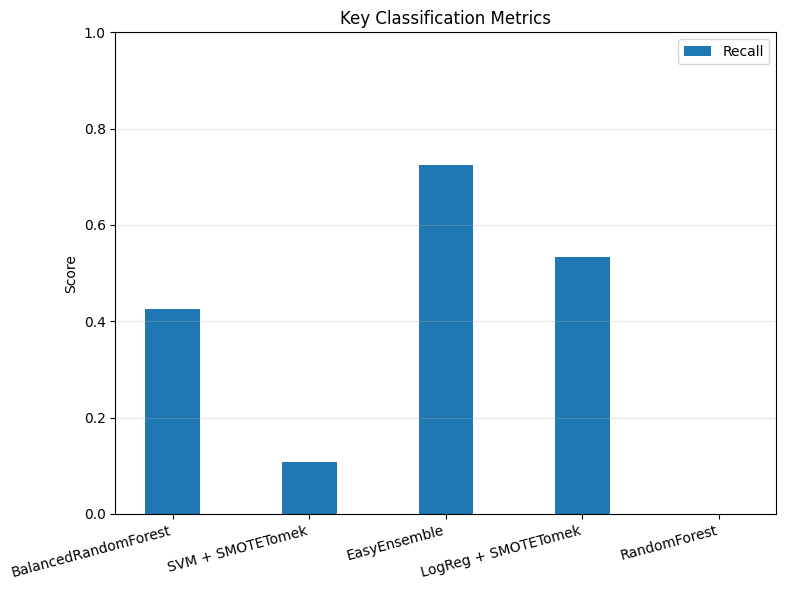

In [ ]:
import matplotlib.pyplot as plt

# results_df: Model, Accuracy, Precision, Recall, F1 컬럼이 있다고 가정
metrics = ["Recall"]

# 정렬 유지(지금은 F1 내림차순으로 되어있으니 그대로 사용)
plot_df = results_df.copy()

x = np.arange(len(plot_df["Model"]))
width = 0.4  # 막대 폭(4개라서 조금 얇게)

plt.figure(figsize=(8, 6))

for i, m in enumerate(metrics):
    plt.bar(x + (i - (len(metrics)-1)/2) * width, plot_df[m].values, width, label=m)

plt.title("Key Classification Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.0)

plt.xticks(x, plot_df["Model"], rotation=15, ha="right")

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# 최종 모델 - EasyEnsemble

## 위험 스코어 산출

In [42]:
easy_model = EasyEnsembleClassifier(random_state=47, n_jobs=1)

out = eval_quarter_ensemble(
    base_model=easy_model,
    use_smote=False,
    min_rows=30
)


In [44]:
result_df = X_test.copy()
result_df["true_label"] = y_test.values
result_df["폐업확률_p"] = out["avg_proba"]
result_df["RiskScore"] = out["risk_score"]

result_df

,여성_합계_mean,가맹점 운영개월수 구간_mean,배달매출금액 비율_std,60대_합계_mean,20대_합계_mean,배달매출금액 비율_mean,배달여부,30대_합계_mean,50대_합계_mean,객단가 구간_mean,60대_합계_std,동일 업종 내 해지 가맹점 비중_std,객단가 구간_std,상권_활성화지수,true_label,폐업확률_p,RiskScore
5829,58.391550,6.0,0.000000,3.000000,45.100000,6.100000,1.0,24.400000,9.950000,4.000000,0.424264,0.636396,0.000000,2.755661,0,0.546570,55
27383,73.057567,3.0,0.000000,19.600000,2.400000,0.000000,0.0,14.000000,32.600000,3.000000,0.264575,0.450925,0.000000,0.697594,0,0.553636,55
21271,52.017667,4.0,0.000000,3.433333,42.933333,0.000000,0.0,43.966667,4.333333,1.333333,0.251661,0.208167,0.577350,0.923612,0,0.517167,52
5515,30.376800,3.0,2.025669,3.266667,16.833333,3.066667,1.0,41.833333,16.633333,5.000000,0.230940,2.253886,0.000000,3.002857,0,0.513634,51
5001,71.466667,5.0,3.839705,1.400000,53.666667,11.666667,1.0,31.566667,7.166667,4.000000,0.100000,0.057735,0.000000,1.439079,0,0.543001,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23529,21.560233,2.0,0.000000,18.400000,9.500000,0.000000,0.0,33.600000,18.400000,4.000000,0.953939,0.556776,0.000000,2.163404,0,0.475132,48
3566,50.750133,2.0,1.081665,23.200000,15.833333,8.000000,1.0,23.166667,19.600000,2.000000,0.264575,0.251661,0.000000,2.163404,0,0.476959,48
2611,39.266667,1.0,0.000000,35.000000,3.433333,0.000000,0.0,15.133333,28.500000,3.000000,0.600000,0.115470,0.000000,0.622461,0,0.364640,36
24373,34.011267,4.0,0.000000,29.833333,5.633333,0.000000,0.0,21.366667,23.666667,3.333333,0.642910,0.450925,2.516611,2.163404,0,0.476701,48


## SHAP로 “개별 점포”의 위험 요인 확인

In [66]:
'''
모델이 어떤 scaler로 변환했는지, 어떤 모델로 학습했는지
'''
trained = out["trained"] # (scaler, model) 리스트

In [67]:
# 분기 앙상블 최종 확률 함수

def predict_proba_ensemble(X_raw_df, trained):
    # X_raw_df: 원본 스케일(표준화 전) DataFrame
    probas = []
    for scaler, model in trained:
        X_scaled = scaler.transform(X_raw_df)
        probas.append(model.predict_proba(X_scaled)[:, 1])
    avg_p = np.mean(np.vstack(probas), axis=0)
    # shap은 보통 2d 출력도 받기 때문에 (n,2)로 반환해도 되고,
    # 여기선 positive class 확률만 쓰는 형태로 진행
    return avg_p


In [55]:
# (1) background: SHAP 기준 데이터(샘플링)
background = X_test.sample(200, random_state=42)

# (2) 설명 대상 점포 선택(예: RiskScore 상위 1개)
risk_scores = out["risk_score"]
top_idx = np.argmax(risk_scores)
x_explain = X_test.iloc[[top_idx]]  # DataFrame 형태 유지(중요)

# (3) Explainer (model-agnostic)
explainer = shap.Explainer(
    lambda X: predict_proba_ensemble(pd.DataFrame(X, columns=X_test.columns), trained),
    background
)

# (4) SHAP 값 계산 (단일 점포)
shap_values = explainer(x_explain)


PermutationExplainer explainer: 2it [00:32, 32.62s/it]               


In [56]:
# shap_values.values: (1, n_features) 또는 (n_features,) 환경에 따라 다를 수 있어 flatten 처리
sv = np.array(shap_values.values).reshape(-1)
feat = np.array(X_test.columns)

# 절대값 기준 Top 10
top_n = 10
top_idx = np.argsort(np.abs(sv))[::-1][:top_n]

top_factors = pd.DataFrame({
    "feature": feat[top_idx],
    "shap_value": sv[top_idx],
    "direction": np.where(sv[top_idx] >= 0, "위험↑", "위험↓")
})

top_factors


,feature,shap_value,direction
0,여성_합계_mean,0.037354,위험↑
1,20대_합계_mean,0.037342,위험↑
2,상권_활성화지수,0.029341,위험↑
3,50대_합계_mean,0.028184,위험↑
4,30대_합계_mean,0.019681,위험↑
5,60대_합계_std,0.016021,위험↑
6,60대_합계_mean,0.011689,위험↑
7,객단가 구간_mean,0.010829,위험↑
8,가맹점 운영개월수 구간_mean,0.010650,위험↑
9,동일 업종 내 해지 가맹점 비중_std,-0.005938,위험↓


## 소상공인 폐업 위험 진단 리포트

In [38]:
# RULEBOOK: 피처별 진단/액션 가이드
RULEBOOK = {
    # -------------------------
    # 고객구성(성별/연령) - mean
    # -------------------------
    "여성_합계_mean": {
        "category": "고객구성",
        "feature_kind": "mean",   # mean / std / immutable
        "actionable": True,
        "high": {
            "diagnosis": "여성 고객 비중(또는 여성 유입 지표)이 기준 대비 높아, 특정 고객층 의존도가 커진 상태입니다.",
            "actions": [
                "남성/가족/직장인 등 다른 고객군을 겨냥한 메뉴(세트/구성) 또는 프로모션을 추가하세요.",
                "시간대별(점심/저녁) 타깃을 분리해 고객 믹스를 분산시키세요."
            ]
        },
        "low": {
            "diagnosis": "여성 고객 유입이 기준 대비 낮아, 핵심 고객군이 약해졌을 가능성이 있습니다.",
            "actions": [
                "여성 선호 메뉴/구성(가성비 세트, 깔끔한 메뉴 설명, 후기 유도)을 강화하세요.",
                "재방문을 유도하는 쿠폰/스탬프를 여성 고객 이용 시간대에 맞춰 운영하세요."
            ]
        }
    },

    "20대_합계_mean": {
        "category": "고객구성",
        "feature_kind": "mean",
        "actionable": True,
        "high": {
            "diagnosis": "20대 고객 비중이 기준 대비 높아, 유행/경쟁/가격 민감도 변화에 취약할 수 있습니다.",
            "actions": [
                "가격대(메뉴 라인업)를 2~3단으로 나눠 이탈을 줄이세요(저가/주력/프리미엄).",
                "SNS/리뷰에만 의존하지 말고, 단골화(리피트 쿠폰/멤버십) 장치를 추가하세요."
            ]
        },
        "low": {
            "diagnosis": "20대 고객 비중이 기준 대비 낮아, 신규 유입(트렌드 유입)이 약할 수 있습니다.",
            "actions": [
                "입문 메뉴(대표 1~2개)와 시그니처 메시지를 명확히 하세요(첫 방문 장벽↓).",
                "지도/리뷰 채널(키워드, 사진, 메뉴판)을 정비해 유입 경로를 강화하세요."
            ]
        }
    },

    "30대_합계_mean": {
        "category": "고객구성",
        "feature_kind": "mean",
        "actionable": True,
        "high": {
            "diagnosis": "30대 고객 비중이 기준 대비 높아, 가족/직장인 수요에 맞춘 운영이 중요합니다.",
            "actions": [
                "점심/저녁 회전(대기/픽업) 동선을 개선해 체감 만족도를 올리세요.",
                "가성비/품질 일관성(맛/양/속도)을 안정화하세요."
            ]
        },
        "low": {
            "diagnosis": "30대 고객 비중이 기준 대비 낮아, 핵심 소비층 유입이 약할 수 있습니다.",
            "actions": [
                "직장인/가족 단위 수요를 겨냥한 세트 메뉴(1~2인/가족)를 구성하세요.",
                "피크타임(점심/저녁) 운영 품질(속도/응대)을 점검하세요."
            ]
        }
    },

    "50대_합계_mean": {
        "category": "고객구성",
        "feature_kind": "mean",
        "actionable": True,
        "high": {
            "diagnosis": "50대 고객 비중이 기준 대비 높아, 재방문/추천 기반 운영이 성패를 좌우할 수 있습니다.",
            "actions": [
                "단골 관리(명함/쿠폰/스탬프)로 재방문율을 구조적으로 확보하세요.",
                "메뉴 설명/가독성(가격표, 사진, 안내)을 정리해 선택 피로를 줄이세요."
            ]
        },
        "low": {
            "diagnosis": "50대 고객 비중이 기준 대비 낮아, 안정적 고정 수요가 약할 수 있습니다.",
            "actions": [
                "지역 커뮤니티/단체 수요(모임/예약)를 위한 옵션을 마련하세요.",
                "방문 편의(좌석, 안내, 결제) 포인트를 개선하세요."
            ]
        }
    },

    "60대_합계_mean": {
        "category": "고객구성",
        "feature_kind": "mean",
        "actionable": True,
        "high": {
            "diagnosis": "60대 고객 비중이 기준 대비 높아, 안정 수요를 유지하는 운영이 중요합니다.",
            "actions": [
                "메뉴/서비스 일관성(맛/양/속도)을 우선으로 안정화하세요.",
                "단골 중심 채널(전화 예약/단골 쿠폰)을 강화하세요."
            ]
        },
        "low": {
            "diagnosis": "60대 고객 비중이 기준 대비 낮아, 지역 고정 수요 기반이 약할 수 있습니다.",
            "actions": [
                "지역 기반 노출(간판/지도/검색 키워드/사진)을 정비하세요.",
                "가족 동반 수요를 위한 메뉴 옵션(맵기/양)을 추가하세요."
            ]
        }
    },

    # -------------------------
    # 변동성 - std
    # -------------------------
    "60대_합계_std": {
        "category": "고객구성",
        "feature_kind": "std",
        "actionable": True,
        "high": {
            "diagnosis": "60대 고객 유입 변동성이 기준 대비 커서, 매출 안정성이 떨어질 수 있습니다.",
            "actions": [
                "단골화(재방문 혜택)로 유입 변동을 줄이세요.",
                "메뉴/운영을 단순화해 ‘항상 같은 경험’을 제공하세요."
            ]
        },
        "low": {
            "diagnosis": "60대 고객 유입 변동성이 기준 대비 낮아, 비교적 안정적으로 유지되고 있습니다.",
            "actions": [
                "현재 운영 품질(맛/속도/응대)을 유지하며, 단골 유지에 집중하세요."
            ]
        }
    },

    # -------------------------
    # 상권
    # -------------------------
    "상권_활성화지수": {
        "category": "상권",
        "feature_kind": "mean",
        "actionable": True,
        "high": {
            "diagnosis": "상권 활성화지수가 기준 대비 높아 경쟁 강도가 높을 수 있습니다(유동은 많지만 선택도 많음).",
            "actions": [
                "대표 메뉴 1~2개를 명확히 하고, 차별 포인트(맛/양/속도/후기)를 강화하세요.",
                "재방문 장치(쿠폰/리뷰 혜택/멤버십)로 ‘단골 전환’을 최우선 과제로 두세요."
            ]
        },
        "low": {
            "diagnosis": "상권 활성화지수가 기준 대비 낮아 수요 자체가 약할 수 있습니다(유입 확보가 핵심).",
            "actions": [
                "유입 채널(지도/검색/리뷰/사진/메뉴판)을 정비해 발견 가능성을 높이세요.",
                "근거리 고객(직장/주거) 타깃을 명확히 하고 시간대 프로모션을 운영하세요."
            ]
        }
    },

    # -------------------------
    # 가격
    # -------------------------
    "객단가_구간_mean": {
        "category": "가격",
        "feature_kind": "mean",
        "actionable": True,
        "high": {
            "diagnosis": "객단가가 기준 대비 높아 가격 저항/경쟁 대비 체감가치 문제가 생길 수 있습니다.",
            "actions": [
                "‘주력 가격대’ 메뉴를 명확히 하고, 고가 메뉴는 스토리/구성(세트)로 납득감을 높이세요.",
                "후기/사진 품질을 개선해 ‘가격 대비 가치’를 증명하세요."
            ]
        },
        "low": {
            "diagnosis": "객단가가 기준 대비 낮아 마진/고정비를 감당하기 어려울 수 있습니다.",
            "actions": [
                "세트 구성/사이드 업셀로 객단가를 자연스럽게 올리세요(강제 인상 X).",
                "원가 구조를 점검하고 ‘덜 팔아도 남는’ 메뉴를 주력으로 재배치하세요."
            ]
        }
    },

    # -------------------------
    # 운영기간(바꾸기 어려움)
    # -------------------------
    "가맹점 운영개월수_구간_mean": {
        "category": "운영",
        "feature_kind": "immutable",
        "actionable": False,
        "high": {
            "diagnosis": "운영기간 지표가 기준 대비 높습니다(운영 이력이 긴 편).",
            "actions": ["이 지표 자체는 바꾸기 어렵기 때문에, 다른 행동 가능한 요인(고객/가격/채널)을 우선 개선하세요."]
        },
        "low": {
            "diagnosis": "운영기간 지표가 기준 대비 낮습니다(초기/안정화 구간일 수 있음).",
            "actions": ["초기에는 변동이 커질 수 있으니, 재방문/리뷰/대표메뉴 고정으로 빠르게 안정화하세요."]
        }
    },

    # -------------------------
    # 경쟁 환경 변동성(외부 요인 성격 강함)
    # -------------------------
    "동일 업종 내 해지 가맹점 비중_std": {
        "category": "상권/경쟁",
        "feature_kind": "std",
        "actionable": "semi",  # 완전 통제는 어렵지만 대응은 가능
        "high": {
            "diagnosis": "동일 업종 해지 비중의 변동성이 커서 시장 상황이 불안정할 수 있습니다.",
            "actions": [
                "고정비를 점검하고, 변동비 중심(재료/인력)으로 운영 유연성을 확보하세요.",
                "단골화/재방문을 최우선으로 해 외부 충격을 줄이세요."
            ]
        },
        "low": {
            "diagnosis": "동일 업종 해지 비중 변동성이 낮아 경쟁 환경이 비교적 안정적일 수 있습니다.",
            "actions": [
                "외부 요인보다 내부 요인(고객 믹스/가격/채널)을 우선 점검하는 것이 효율적입니다."
            ]
        }
    },
    # -------------------------
    # 배달
    # -------------------------
    "배달매출금액 비율_mean": {
        "category": "배달",
        "feature_kind": "mean",
        "actionable": True,
        "high": {
            "diagnosis": "배달매출 비중이 기준 대비 높아, 플랫폼 의존도가 커진 상태입니다.",
            "actions": [
                "플랫폼 수수료·프로모션 비용을 점검하고, 마진이 남는 메뉴만 배달 주력으로 운영하세요.",
                "배달 전용 메뉴와 매장 전용 메뉴를 분리해 수익 구조를 명확히 하세요.",
                "단골 고객을 위한 자체 채널(전화 주문, 포장 할인) 비중을 점진적으로 늘리세요."
            ]
        },
        "low": {
            "diagnosis": "배달매출 비중이 기준 대비 낮아, 외부 유입(비대면 수요)을 충분히 활용하지 못하고 있을 수 있습니다.",
            "actions": [
                "대표 메뉴 1~2개를 배달 친화적으로 구성해 테스트 운영을 시작하세요.",
                "사진·메뉴 설명·리뷰 관리 등 배달 플랫폼 기본 노출 요소를 정비하세요.",
                "피크타임(점심/저녁)에 한정된 배달 프로모션으로 부담 없이 수요를 확인하세요."
            ]
        }
    },

    "배달매출금액 비율_std": {
        "category": "배달",
        "feature_kind": "std",
        "actionable": True,
        "high": {
            "diagnosis": "배달매출 비율의 변동성이 커서, 특정 이벤트나 프로모션에 매출이 크게 흔들리고 있습니다.",
            "actions": [
                "상시 판매 가능한 ‘고정 배달 메뉴’를 선정해 매출 변동을 줄이세요.",
                "과도한 할인 이벤트는 줄이고, 리뷰·재주문 혜택 중심으로 구조를 단순화하세요.",
                "배달 운영 시간과 메뉴 수를 줄여 품질과 일관성을 확보하세요."
            ]
        },
        "low": {
            "diagnosis": "배달매출 비율이 비교적 안정적으로 유지되고 있습니다.",
            "actions": [
                "현재 배달 메뉴 구성과 운영 방식을 유지하면서 원가·수수료 효율만 주기적으로 점검하세요."
            ]
        }
    },

    # -------------------------
    # 가격 (변동성)
    # -------------------------
    "객단가_구간_std": {
        "category": "가격",
        "feature_kind": "std",
        "actionable": True,
        "high": {
            "diagnosis": "객단가 변동성이 커서, 고객 구매 패턴이 불안정한 상태입니다.",
            "actions": [
                "주력 메뉴 가격대를 명확히 하고 선택지를 줄여 구매 기준을 단순화하세요.",
                "세트 메뉴를 고정해 주문당 매출 편차를 줄이세요.",
                "프로모션 시 할인 폭을 줄이고 구성(사이드·음료) 중심으로 조정하세요."
            ]
        },
        "low": {
            "diagnosis": "객단가가 비교적 일정해 매출 예측 가능성이 높습니다.",
            "actions": [
                "현재 가격 구조를 유지하되, 소폭 업셀(사이드·추가 옵션)을 테스트해 보세요."
            ]
        }
    },

    # -------------------------
    # 배달 운영 여부
    # -------------------------
    "배달여부": {
        "category": "배달",
        "feature_kind": "immutable",
        "actionable": "semi",
        "high": {
            "diagnosis": "배달 서비스를 운영 중인 상태입니다.",
            "actions": [
                "배달이 실제 수익에 기여하는지(마진 기준) 정기적으로 점검하세요.",
                "배달·매장 운영 동선을 분리해 피크타임 품질 저하를 방지하세요."
            ]
        },
        "low": {
            "diagnosis": "배달 서비스를 운영하지 않고 있어, 매장 방문 수요에 전적으로 의존하고 있습니다.",
            "actions": [
                "포장(테이크아웃) 할인부터 시작해 배달 전환 가능성을 단계적으로 검토하세요.",
                "배달 없이도 유지 가능한 고정 고객·상권 기반이 있는지 점검하세요."
            ]
        }
    },       

}


In [44]:
def _flatten_shap(shap_values):
    """shap_values.values 형태 차이를 흡수해 1차원 배열로 통일"""
    sv = np.array(shap_values.values)
    return sv.reshape(-1)

def _get_reference_value(X_ref, feature, rulebook):
    """
    기준선(reference) 요약값
    - rulebook[feature]["feature_kind"]에 따라 자동 계산
    """
    meta = rulebook.get(feature, {})
    kind = meta.get("feature_kind", "mean")

    # 1) 변동성 지표 → std 기준
    if kind == "std":
        return float(X_ref[feature].std(ddof=0))

    # 2) 평균 수준 지표 → mean
    if kind in ["mean", "immutable"]:
        return float(X_ref[feature].mean())

    # 3) 예외 대비 기본값
    return float(X_ref[feature].mean())


# 핵심 함수
def build_actionable_insights(
    x_explain: pd.DataFrame,
    shap_values,
    X_ref: pd.DataFrame, #기준선 데이터
    rulebook: dict,
    top_n: int = 5, 
    min_abs_shap: float = 0.0,  # 너무 작은 기여도는 제외하고 싶으면 값 올리기
):
    """
    반환: 소상공인용 인사이트 리스트(상위 top_n)
    """
    assert isinstance(x_explain, pd.DataFrame) and len(x_explain) == 1, "x_explain은 1행 DataFrame이어야 합니다."
    
    sv = _flatten_shap(shap_values)
    features = list(x_explain.columns)

    # Top 후보: rulebook에 존재하는 피처 중 |SHAP| 큰 순
    candidates = []
    for i, f in enumerate(features):
        if f not in rulebook:
            continue
        if abs(float(sv[i])) < min_abs_shap:
            continue
        candidates.append((f, float(sv[i])))

    candidates = sorted(candidates, key=lambda x: abs(x[1]), reverse=True)[:top_n]

    insights = []
    for f, shap_v in candidates:
        my_val = float(x_explain.iloc[0][f])
        ref_val = _get_reference_value(X_ref, f, rulebook=rulebook)

        # 기준 대비 높/낮 판정
        level = "high" if my_val > ref_val else "low"

        # SHAP 방향: +면 위험 증가, -면 위험 감소
        shap_dir = "위험↑" if shap_v >= 0 else "위험↓"

        meta = rulebook[f]
        tpl = meta[level]

        # 행동 가능성 라벨
        actionable = meta.get("actionable", True)
        if actionable is True:
            action_label = "즉시 개선 가능"
        elif actionable == "semi":
            action_label = "부분 대응 가능"
        else:
            action_label = "모니터링 지표"

        insights.append({
            "feature": f,
            "category": meta.get("category", "기타"),
            "shap_value": shap_v,
            "direction": shap_dir,
            "my_value": my_val,
            "ref_value": ref_val,
            "level_vs_ref": "기준보다 높음" if level == "high" else "기준보다 낮음",
            "actionability": action_label,
            "diagnosis": tpl.get("diagnosis", ""),
            "actions": tpl.get("actions", []),
        })

    return insights


In [47]:
# 기준선(reference): 1차는 X_test 전체 평균
X_ref = X_test

insights = build_actionable_insights(
    x_explain=x_explain,
    shap_values=shap_values,
    X_ref=X_ref,
    rulebook=RULEBOOK,
    top_n=5,
    min_abs_shap=0.0
)



In [48]:
def format_insights_for_report(insights):
    lines = []

    lines.append("📊 소상공인 폐업 위험 진단 리포트")
    lines.append("=" * 60)
    lines.append(f"총 인사이트 수: {len(insights)}")
    lines.append("")

    for k, ins in enumerate(insights, start=1):
        lines.append(f"{k}. [{ins['category']}] {ins['feature']}")
        lines.append(f"   - 위험 방향: {ins['direction']} / {ins['level_vs_ref']}")
        lines.append(f"   - 진단: {ins['diagnosis']}")
        lines.append(f"   - 근거: 현재값 = {ins['my_value']:.4f}, 기준값 = {ins['ref_value']:.4f}")
        lines.append(f"   - 개선 가능성: {ins['actionability']}")

        if ins.get("actions"):
            lines.append("   - 권장 행동:")
            for a in ins["actions"]:
                lines.append(f"     • {a}")
        else:
            lines.append("   - 권장 행동: (해당 없음, 모니터링 권장)")

        lines.append("-" * 60)

    return "\n".join(lines)

report_text = format_insights_for_report(insights)
print(report_text)


📊 소상공인 폐업 위험 진단 리포트
총 인사이트 수: 5

1. [고객구성] 여성_합계_mean
   - 위험 방향: 위험↑ / 기준보다 높음
   - 진단: 여성 고객 비중(또는 여성 유입 지표)이 기준 대비 높아, 특정 고객층 의존도가 커진 상태입니다.
   - 근거: 현재값 = 71.2770, 기준값 = 44.5672
   - 개선 가능성: 즉시 개선 가능
   - 권장 행동:
     • 남성/가족/직장인 등 다른 고객군을 겨냥한 메뉴(세트/구성) 또는 프로모션을 추가하세요.
     • 시간대별(점심/저녁) 타깃을 분리해 고객 믹스를 분산시키세요.
------------------------------------------------------------
2. [배달] 배달매출금액 비율_std
   - 위험 방향: 위험↑ / 기준보다 높음
   - 진단: 배달매출 비율의 변동성이 커서, 특정 이벤트나 프로모션에 매출이 크게 흔들리고 있습니다.
   - 근거: 현재값 = 7.3050, 기준값 = 3.2469
   - 개선 가능성: 즉시 개선 가능
   - 권장 행동:
     • 상시 판매 가능한 ‘고정 배달 메뉴’를 선정해 매출 변동을 줄이세요.
     • 과도한 할인 이벤트는 줄이고, 리뷰·재주문 혜택 중심으로 구조를 단순화하세요.
     • 배달 운영 시간과 메뉴 수를 줄여 품질과 일관성을 확보하세요.
------------------------------------------------------------
3. [고객구성] 20대_합계_mean
   - 위험 방향: 위험↑ / 기준보다 높음
   - 진단: 20대 고객 비중이 기준 대비 높아, 유행/경쟁/가격 민감도 변화에 취약할 수 있습니다.
   - 근거: 현재값 = 61.6667, 기준값 = 22.0471
   - 개선 가능성: 즉시 개선 가능
   - 권장 행동:
     • 가격대(메뉴 라인업)를 2~3단으로 나눠 이탈을 줄이세요(저가/주력/프리미엄).
     • SNS/리뷰에만 

# 그리드 서치 - EasyEnsemble

In [70]:
param_grid = {
    "n_estimators": [50, 100, 200],        # 앙상블 개수
    "sampling_strategy": ["auto", 0.8, 1.0],  # 각 서브셋에서 소수/다수 비율
    "replacement": [False, True],          # 다수 클래스 샘플링 시 복원추출 여부
}

grid_rows = []
for params in ParameterGrid(param_grid):
    # params 반영한 EasyEnsemble 생성
    model = EasyEnsembleClassifier(
        random_state=47,
        n_jobs=1,
        **params
    )

    out = eval_quarter_ensemble(model, use_smote=False, min_rows=30)
    if out is None:
        grid_rows.append({
            "Model": "EasyEnsemble(Grid)",
            "params": params,
            "n_models_used": 0,
            "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "F1": np.nan
        })
    else:
        grid_rows.append({
            "Model": "EasyEnsemble(Grid)",
            "params": params,
            **out
        })

grid_df = pd.DataFrame(grid_rows)

# Recall 최우선, 동률이면 F1 -> Precision -> Accuracy 순(원하면 바꾸세요)
grid_df = grid_df.sort_values(
    ["Recall", "F1", "Precision", "Accuracy"],
    ascending=[False, False, False, False]
)

grid_df


,Model,params,n_models_used,trained,avg_proba,risk_score,Accuracy,Precision,Recall,F1
15,EasyEnsemble(Grid),"{'n_estimators': 200, 'replacement': True, 'sa...",8,"[(StandardScaler(), (Pipeline(steps=[('sampler...","[0.5465411182516978, 0.551738107222959, 0.5085...","[55, 55, 51, 52, 54, 50, 50, 39, 50, 49, 48, 5...",0.486133,0.029267,0.741667,0.056311
17,EasyEnsemble(Grid),"{'n_estimators': 200, 'replacement': True, 'sa...",8,"[(StandardScaler(), (Pipeline(steps=[('sampler...","[0.5465411182516978, 0.551738107222959, 0.5085...","[55, 55, 51, 52, 54, 50, 50, 39, 50, 49, 48, 5...",0.486133,0.029267,0.741667,0.056311
3,EasyEnsemble(Grid),"{'n_estimators': 50, 'replacement': True, 'sam...",8,"[(StandardScaler(), (Pipeline(steps=[('sampler...","[0.5507522337466874, 0.5502558192174464, 0.511...","[55, 55, 51, 51, 55, 50, 50, 40, 50, 49, 48, 5...",0.477519,0.028793,0.741667,0.055434
5,EasyEnsemble(Grid),"{'n_estimators': 50, 'replacement': True, 'sam...",8,"[(StandardScaler(), (Pipeline(steps=[('sampler...","[0.5507522337466874, 0.5502558192174464, 0.511...","[55, 55, 51, 51, 55, 50, 50, 40, 50, 49, 48, 5...",0.477519,0.028793,0.741667,0.055434
9,EasyEnsemble(Grid),"{'n_estimators': 100, 'replacement': True, 'sa...",8,"[(StandardScaler(), (Pipeline(steps=[('sampler...","[0.549710794369298, 0.5521914580432281, 0.5099...","[55, 55, 51, 52, 54, 50, 51, 40, 50, 49, 48, 5...",0.481654,0.028711,0.733333,0.055259
11,EasyEnsemble(Grid),"{'n_estimators': 100, 'replacement': True, 'sa...",8,"[(StandardScaler(), (Pipeline(steps=[('sampler...","[0.549710794369298, 0.5521914580432281, 0.5099...","[55, 55, 51, 52, 54, 50, 51, 40, 50, 49, 48, 5...",0.481654,0.028711,0.733333,0.055259
0,EasyEnsemble(Grid),"{'n_estimators': 50, 'replacement': False, 'sa...",8,"[(StandardScaler(), (Pipeline(steps=[('sampler...","[0.5465152004671364, 0.5501963860846925, 0.507...","[55, 55, 51, 51, 54, 50, 51, 39, 50, 49, 48, 5...",0.491473,0.028942,0.725000,0.055662
2,EasyEnsemble(Grid),"{'n_estimators': 50, 'replacement': False, 'sa...",8,"[(StandardScaler(), (Pipeline(steps=[('sampler...","[0.5465152004671364, 0.5501963860846925, 0.507...","[55, 55, 51, 51, 54, 50, 51, 39, 50, 49, 48, 5...",0.491473,0.028942,0.725000,0.055662
6,EasyEnsemble(Grid),"{'n_estimators': 100, 'replacement': False, 's...",8,"[(StandardScaler(), (Pipeline(steps=[('sampler...","[0.5466961696299358, 0.5497523336994325, 0.504...","[55, 55, 50, 51, 54, 50, 51, 39, 50, 49, 48, 5...",0.490612,0.028894,0.725000,0.055573
8,EasyEnsemble(Grid),"{'n_estimators': 100, 'replacement': False, 's...",8,"[(StandardScaler(), (Pipeline(steps=[('sampler...","[0.5466961696299358, 0.5497523336994325, 0.504...","[55, 55, 50, 51, 54, 50, 51, 39, 50, 49, 48, 5...",0.490612,0.028894,0.725000,0.055573


In [71]:
# 베스트 파라미터/모델 
best_row = grid_df.iloc[0]
best_params = best_row["params"]
best_params, best_row


({'n_estimators': 200, 'replacement': True, 'sampling_strategy': 'auto'},
 Model                                           EasyEnsemble(Grid)
 params           {'n_estimators': 200, 'replacement': True, 'sa...
 n_models_used                                                    8
 trained          [(StandardScaler(), (Pipeline(steps=[('sampler...
 avg_proba        [0.5465411182516978, 0.551738107222959, 0.5085...
 risk_score       [55, 55, 51, 52, 54, 50, 50, 39, 50, 49, 48, 5...
 Accuracy                                                  0.486133
 Precision                                                 0.029267
 Recall                                                    0.741667
 F1                                                        0.056311
 Name: 15, dtype: object)